In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

In [2]:
import pandas as pd

from pathlib import Path

from models.dnn.model import NumpyModel

project_root = Path().resolve().parents[1]


In [3]:
model_path = project_root / "models" / "numpy-dnn.pkl.gz"
model = NumpyModel.load(model_path)

In [4]:
dataset_path = project_root / "src" / "data" / "subm1_labels_revealed.csv"

df = pd.read_csv(dataset_path, sep=";")

In [5]:
X = df["Text"].tolist()
y = df["Label"].tolist()

predicted_labels = model.predict(X, y)

df["Labels"] = predicted_labels

Accuracy: 82/100 (82.00%)


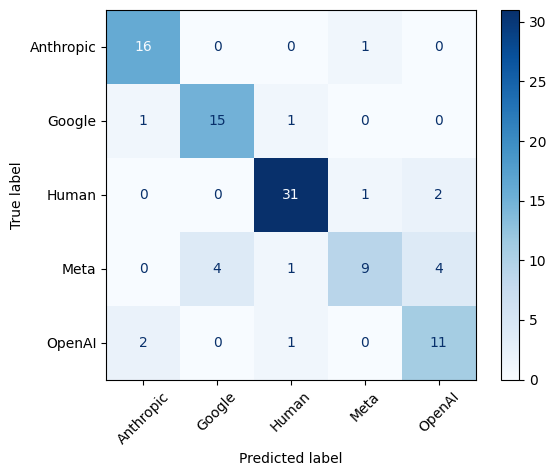

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.label_map.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

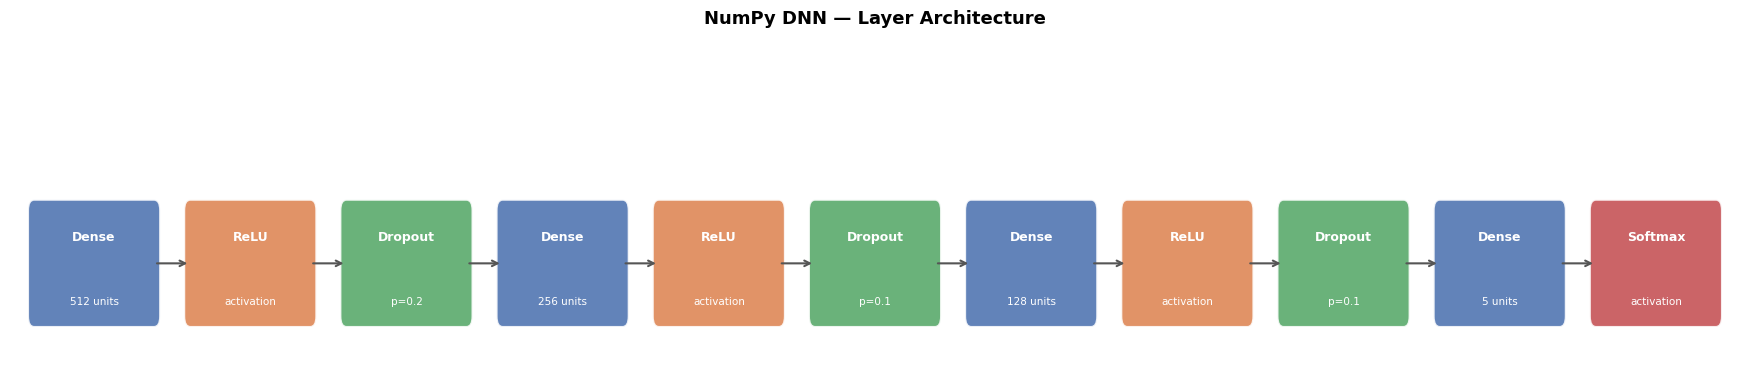

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from models.dnn.classifiers.layers import DenseLayer, ReLU, Dropout, Softmax

# ── collect layer descriptors from the live model ──────────────────────────
def _describe(layer):
    if isinstance(layer, DenseLayer):
        return ("Dense", f"{layer.n_units} units", "#4C72B0")
    if isinstance(layer, ReLU):
        return ("ReLU", "activation", "#DD8452")
    if isinstance(layer, Dropout):
        return ("Dropout", f"p={layer.rate}", "#55A868")
    if isinstance(layer, Softmax):
        return ("Softmax", "activation", "#C44E52")
    return (type(layer).__name__, "", "#8C8C8C")

layers = [_describe(l) for l in model.nn.layers]

# ── draw ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(layers) * 1.6), 4))
ax.axis("off")

BOX_W, BOX_H, GAP = 1.0, 0.5, 0.3
total_w = len(layers) * (BOX_W + GAP) - GAP

for i, (name, detail, color) in enumerate(layers):
    x = i * (BOX_W + GAP)
    # arrow between boxes
    if i > 0:
        ax.annotate("", xy=(x, BOX_H / 2), xytext=(x - GAP, BOX_H / 2),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=1.5))
    rect = mpatches.FancyBboxPatch((x, 0), BOX_W, BOX_H,
                                   boxstyle="round,pad=0.05",
                                   facecolor=color, edgecolor="white",
                                   linewidth=1.5, alpha=0.88)
    ax.add_patch(rect)
    ax.text(x + BOX_W / 2, BOX_H / 2 + 0.12, name,
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    ax.text(x + BOX_W / 2, BOX_H / 2 - 0.18, detail,
            ha="center", va="center", fontsize=7.5, color="white")

ax.set_xlim(-0.2, total_w + 0.2)
ax.set_ylim(-0.3, 1.3)
ax.set_title("NumPy DNN — Layer Architecture", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


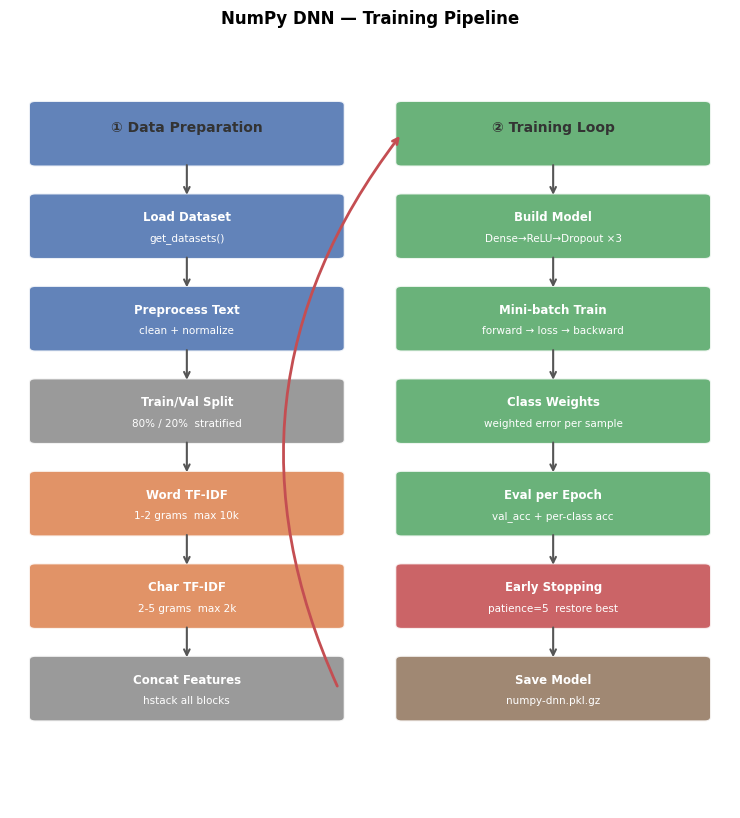

In [8]:
from models.dnn.train import TrainNumpy

# Visualiza o pipeline de treino como flowchart vertical
TrainNumpy.plot_pipeline(enable_tfidf_char=True, enable_handcrafted=False)